In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 34.0 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.1 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="4n8kwkhnvOyEHnWZ7AAr")
project = rf.workspace("nizekiee").project("bucket-0fl8n")
version = project.version(4)
dataset = version.download("yolov8")

print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Bucket-4 in yolov8:: 100%|██████████| 2990/2990 [00:00<00:00, 4894.54it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
/kaggle/working/Bucket-4


In [3]:
import yaml

yaml_path = f"{dataset.location}/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = f"{dataset.location}/train/images"
data['val'] = f"{dataset.location}/valid/images"
data['test'] = f"{dataset.location}/test/images"

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print(data)

{'names': ['bucket'], 'nc': 1, 'roboflow': {'license': 'Private', 'project': 'bucket-0fl8n', 'url': 'https://app.roboflow.com/nizekiee/bucket-0fl8n/4', 'version': 4, 'workspace': 'nizekiee'}, 'test': '/kaggle/working/Bucket-4/test/images', 'train': '/kaggle/working/Bucket-4/train/images', 'val': '/kaggle/working/Bucket-4/valid/images'}


In [4]:
import os, glob
from PIL import Image

sizes = []
for label_file in glob.glob(f"{dataset.location}/train/labels/*.txt"):
    img_file = label_file.replace("labels", "images").replace(".txt", ".jpg")
    if not os.path.exists(img_file):
        img_file = img_file.replace(".jpg", ".png")
    if not os.path.exists(img_file):
        continue
    w, h = Image.open(img_file).size
    with open(label_file) as f:
        for line in f:
            parts = line.split()
            bw, bh = float(parts[3]), float(parts[4])
            sizes.append((bw * w, bh * h))

small = [s for s in sizes if s[0] < 32 or s[1] < 32]
print(f"Total boxes: {len(sizes)}")
print(f"Small (<32px): {len(small)} ({100*len(small)/len(sizes):.1f}%)")

Total boxes: 846
Small (<32px): 174 (20.6%)


In [5]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data=yaml_path,
    epochs=300,
    patience=50,
    imgsz=960,
    batch=16,
    device=0,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    close_mosaic=15,

    optimizer='AdamW',
    lr0=0.001,
    cos_lr=True,

    save_period=10,
    project='/kaggle/working/worker_detection',
    name='v1_960_s',
    exist_ok=True
)

Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Bucket-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1_960_s, nbs=64, nms=None, opset=None, optimize=False

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/300      7.32G      1.367     0.9008      1.179          6        960: 100% ━━━━━━━━━━━━ 66/66 2.8it/s 23.2s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.8it/s 3.6s.4ss
                   all        295        291       0.97      0.902      0.954      0.541

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/300      7.33G      1.297      0.835      1.159          7        960: 100% ━━━━━━━━━━━━ 66/66 2.8it/s 23.7s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.7it/s 3.8s.4ss
                   all        295        291      0.953       0.91      0.942      0.522

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/300      7.36G      1.289     0.8113       1.15          6        960: 100% ━━━━━━━━━━━━ 66/66 2.8it/s 23.8s0.3ss
                 Class     Images  I

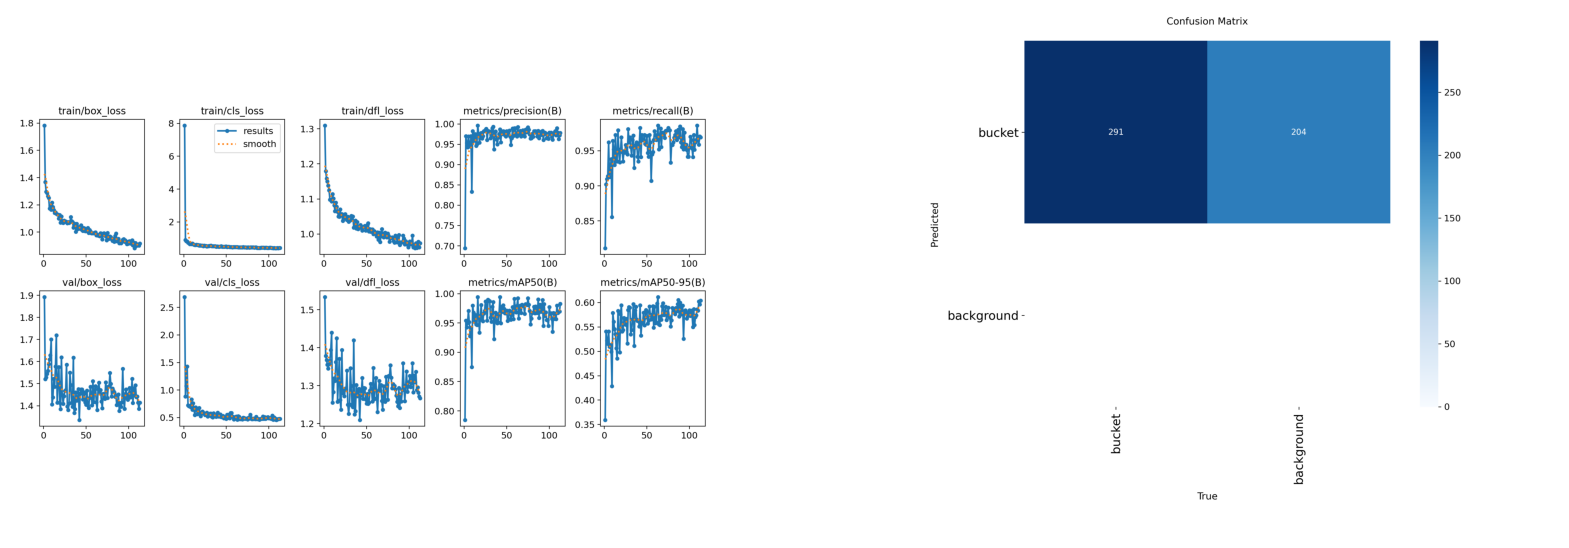

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

run_dir = '/kaggle/working/worker_detection/v1_960_s'

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(mpimg.imread(f'{run_dir}/results.png'))
axes[0].axis('off')
axes[1].imshow(mpimg.imread(f'{run_dir}/confusion_matrix.png'))
axes[1].axis('off')
plt.show()

In [7]:
metrics = model.val(data=yaml_path, imgsz=960, split='test')
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2848.4±419.1 MB/s, size: 180.6 KB)
val: Scanning /kaggle/working/Bucket-4/test/labels... 152 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 152/152 1.3Kit/s 0.1s<0.1s
val: New cache created: /kaggle/working/Bucket-4/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.9it/s 5.2s.4ss
                   all        152        141      0.992          1      0.994      0.651
Speed: 5.3ms preprocess, 19.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50: 0.9939
mAP50-95: 0.6508


In [8]:
import shutil
shutil.make_archive('/kaggle/working/final_model_backup', 'zip', '/kaggle/working/worker_detection/v1_960_s')
print("✓ Zipped and ready")

✓ Zipped and ready


In [9]:
import importlib.util
required_modules = ['ultralytics', 'torch', 'numpy', 'pandas', 'yaml', 'matplotlib', 'PIL']
missing = [m for m in required_modules if importlib.util.find_spec(m) is None]
if missing:
    raise RuntimeError(f"Missing dependencies: {missing}. Install the training-version dependencies first.")
import ultralytics
print('Evaluation Ultralytics version:', ultralytics.__version__)
# เฉพาะ runtime ใหม่และเวอร์ชันตรงกับการเทรน:
# !pip install ultralytics==8.4.130 pandas matplotlib pyyaml pillow


Evaluation Ultralytics version: 8.4.171


In [26]:
# ถ้าวางเซลล์นี้ต่อท้าย notebook เทรนเดิมและยังมี model.trainer:
# RUN_DIR = str(model.trainer.save_dir)

RUN_DIR = "/kaggle/working/worker_detection/v1_960_s"             # ใส่โฟลเดอร์ผลเทรน Bucket จริง
DATA_YAML = ""           # ว่าง = ใช้ args.yaml; ใส่ path ใหม่ถ้าย้ายเครื่อง
EXPECTED_CLASS = "bucket"
OPERATIONAL_CONF = 0.70   # None = เลือก max mean F1 curve จาก Validation เท่านั้น
DEVICE = None            # None = เลือก GPU ถ้ามี, ไม่งั้น CPU
MANIFEST_CSV = None      # optional: image_path,split,camera,group_id ครอบคลุมทุกภาพ
BEST_EPOCH_FROM_LOG = None
SAMPLE_COUNT = 6          # ตัวอย่าง Test ที่เลือกแบบกระจายตามลำดับ ไม่คัดแต่ภาพดี

# ตัวอย่างเฉพาะ Worker ที่แนบ (อย่าใช้เป็นผล Bucket):
# RUN_DIR = "/kaggle/working/worker_detection/v1_960_s"
# DATA_YAML = "/kaggle/working/Worker-7/data.yaml"
# EXPECTED_CLASS = "worker"
# OPERATIONAL_CONF = <เกณฑ์ Worker ในโค้ดระบบจริง>
# BEST_EPOCH_FROM_LOG = 114


In [27]:
from pathlib import Path

print("RUN_DIR:", RUN_DIR)
print("พบ best.pt:", (Path(RUN_DIR) / "weights" / "best.pt").is_file())
print("ตั้งค่าแล้ว — ให้รันเซลล์สร้างรายงานต่อ")

RUN_DIR: /kaggle/working/worker_detection/v1_960_s
พบ best.pt: True
ตั้งค่าแล้ว — ให้รันเซลล์สร้างรายงานต่อ


In [29]:
if not RUN_DIR.strip():
    raise ValueError("กรอก RUN_DIR ของรอบเทรนจริงในเซลล์ 2 ก่อน")

report = export_report(
    run_dir=RUN_DIR,
    data_yaml=DATA_YAML or None,
    expected_class=EXPECTED_CLASS,
    operational_conf=OPERATIONAL_CONF,
    device=DEVICE,
    manifest_csv=MANIFEST_CSV,
    sample_count=SAMPLE_COUNT,
    best_epoch_from_log=BEST_EPOCH_FROM_LOG,
)
from IPython.display import display, FileLink
display(report['standard_metrics'])
display(report['operational_metrics'])
display(FileLink(report['zip_path']))
# Kaggle: ดาวน์โหลดจากแถบ Output / Files
# Colab: ดาวน์โหลด ZIP ตาม path ที่พิมพ์ด้านบน หรือใช้เซลล์ถัดไป


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3145.8±359.3 MB/s, size: 181.0 KB)
val: Scanning /kaggle/working/Bucket-4/valid/labels.cache... 295 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 295/295 103.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.4it/s 8.0s0.4s
                   all        295        291      0.993      0.986      0.992      0.609
Speed: 3.1ms preprocess, 18.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/worker_detection/v1_960_s/thesis_report_20261001_174341_626046/ultralytics/validation
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultr

,split,class,Precision,Recall,F1,AP50,AP50_95,operating_point
0,val,bucket,0.992506,0.986254,0.989370,0.991762,0.608635,Ultralytics summary max-F1 point; not deployme...
1,test,bucket,0.991765,1.000000,0.995865,0.993803,0.646664,Ultralytics summary max-F1 point; not deployme...


,split,class,confidence,matching_IoU,TP,FP,FN,Precision,Recall,F1,matching
0,test,bucket,0.7,0.5,135,1,6,0.992647,0.957447,0.974729,"class-agnostic greedy descending IoU, one-to-one"


/kaggle/working/worker_detection/v1_960_s/thesis_report_20261001_174341_626046_package.zip

In [30]:
# แม่แบบที่กรอกตัวเลขจริงแล้ว หน่วยวินาที
TIMING_CSV = ""
TIMING_OUTPUT_DIR = "/kaggle/working/pouring_time_evaluation"  # Colab ใช้ /content/...
TIMING_TOLERANCE_SEC = 5.0  # ตัวอย่างค่าตั้งต้น; กำหนดก่อนดูผล ไม่ใช่มาตรฐานสากล

if TIMING_CSV:
    timing = evaluate_pouring_times(TIMING_CSV, TIMING_OUTPUT_DIR, TIMING_TOLERANCE_SEC)
    display(timing['comparison'])
    display(timing['summary'])
    timing_zip = shutil.make_archive(str(Path(TIMING_OUTPUT_DIR).resolve()) + "_package", 'zip', TIMING_OUTPUT_DIR)
    display(FileLink(timing_zip))
else:
    print("ยังไม่ประเมินเวลา: กรอกค่าจริงใน pouring_times_template.csv แล้วตั้ง TIMING_CSV")


ยังไม่ประเมินเวลา: กรอกค่าจริงใน pouring_times_template.csv แล้วตั้ง TIMING_CSV


คลาสในโมเดล: {0: 'bucket'}
กำลังสร้างกราฟจาก best.pt บนชุด Test — ไม่ได้เทรนใหม่
Ultralytics 8.4.171 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2926.6±899.0 MB/s, size: 173.4 KB)
val: Scanning /kaggle/working/Bucket-4/test/labels.cache... 152 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 152/152 16.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.0it/s 5.1s.4ss
                   all        152        141      0.992          1      0.994      0.651
Speed: 5.3ms preprocess, 19.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/thesis_graphs_20261001_180126_586028/test_evaluation
01_training_results.png


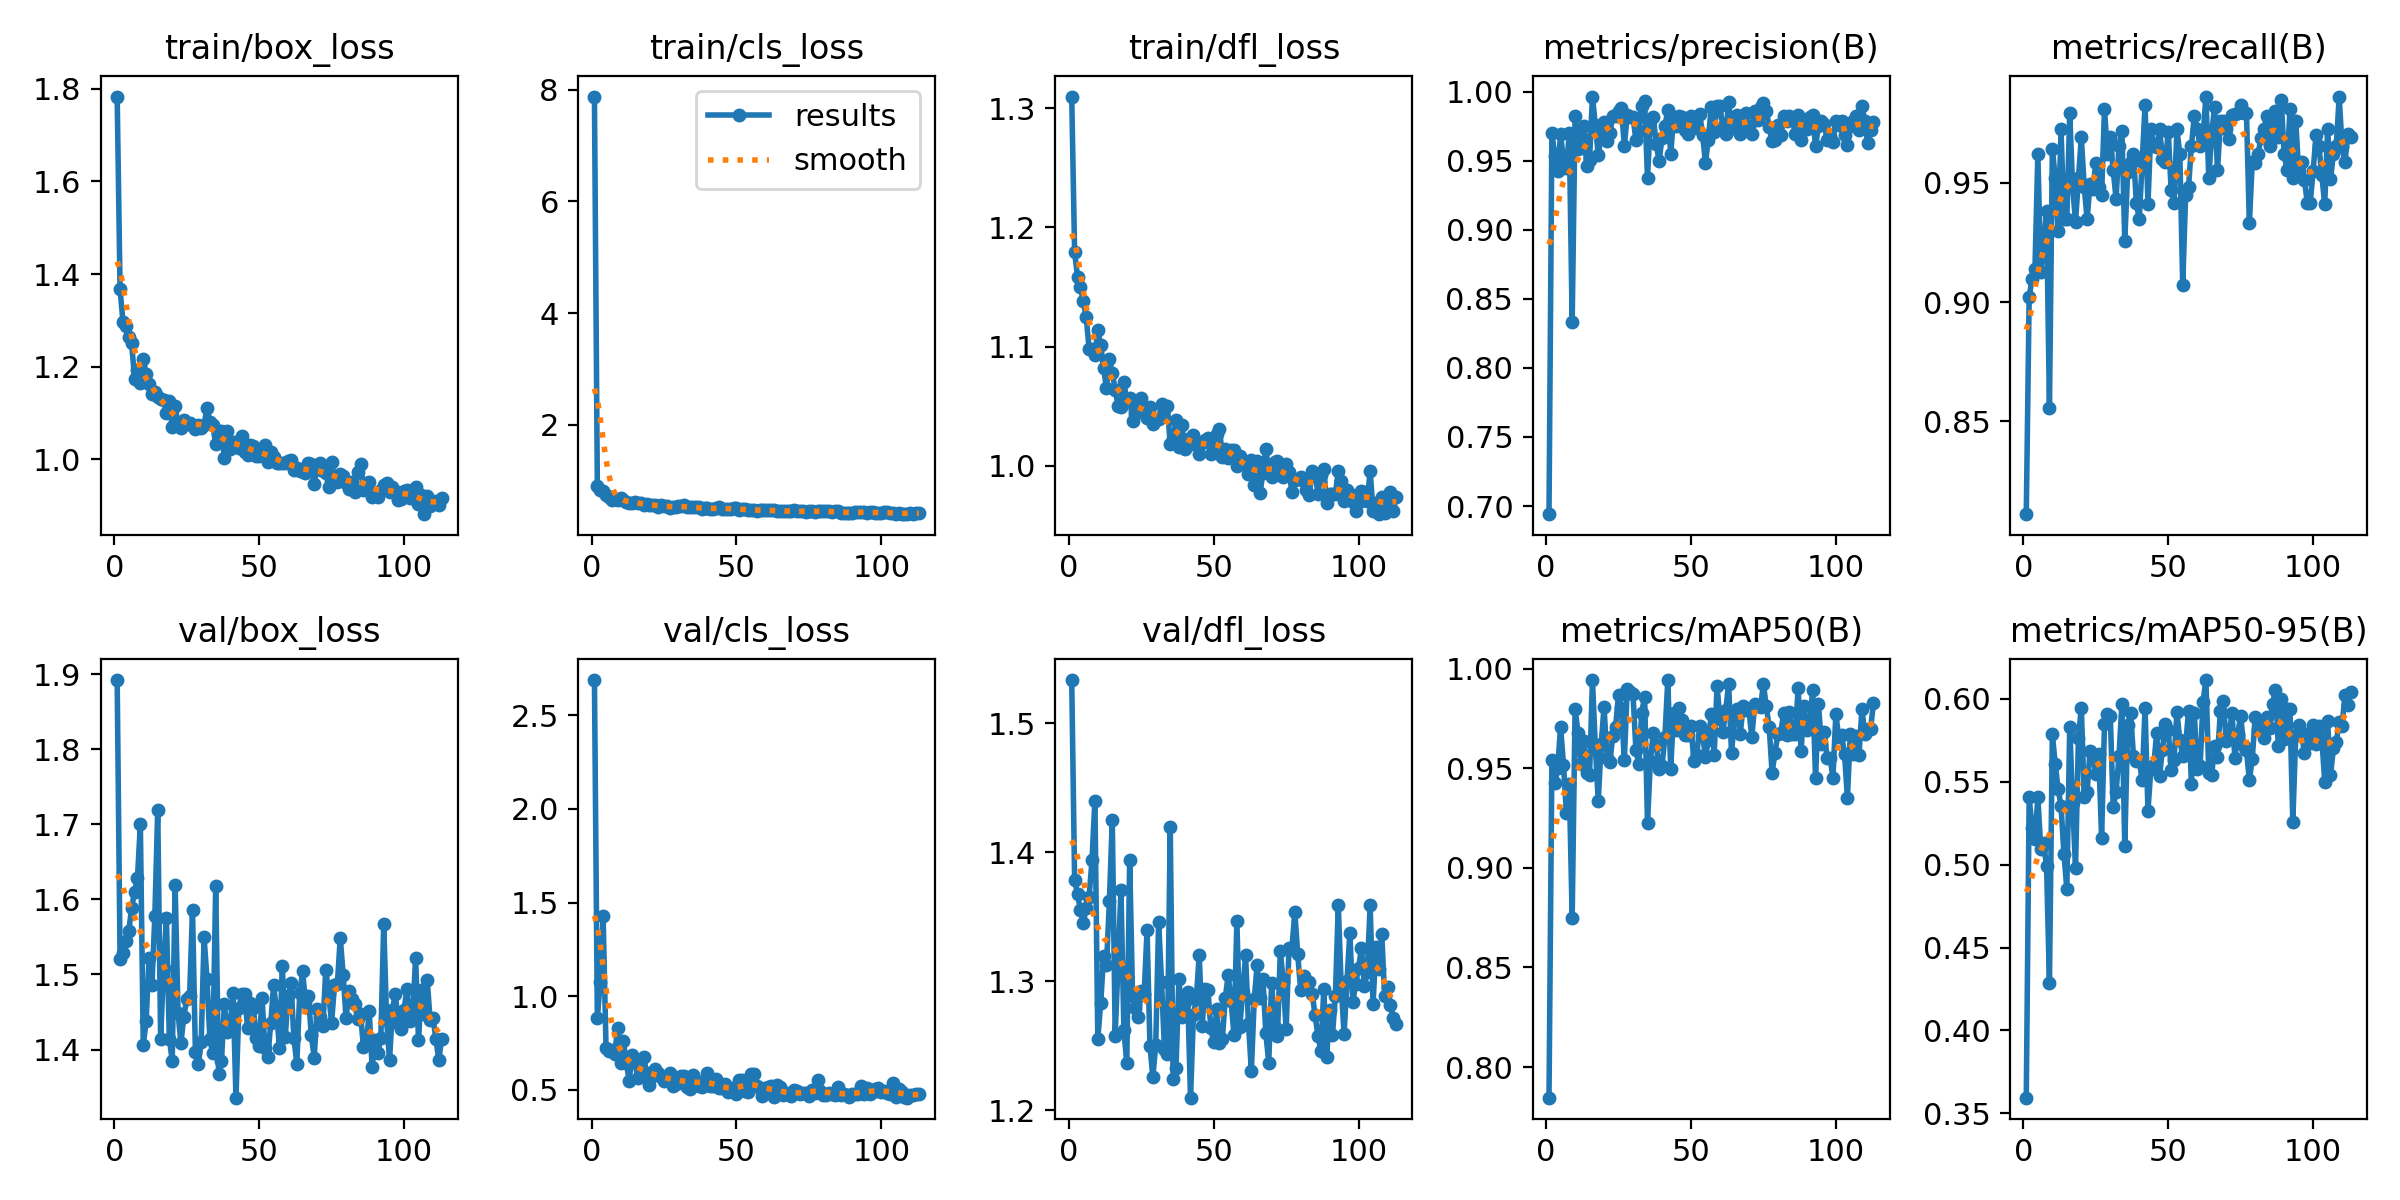

02_test_PR_curve.png


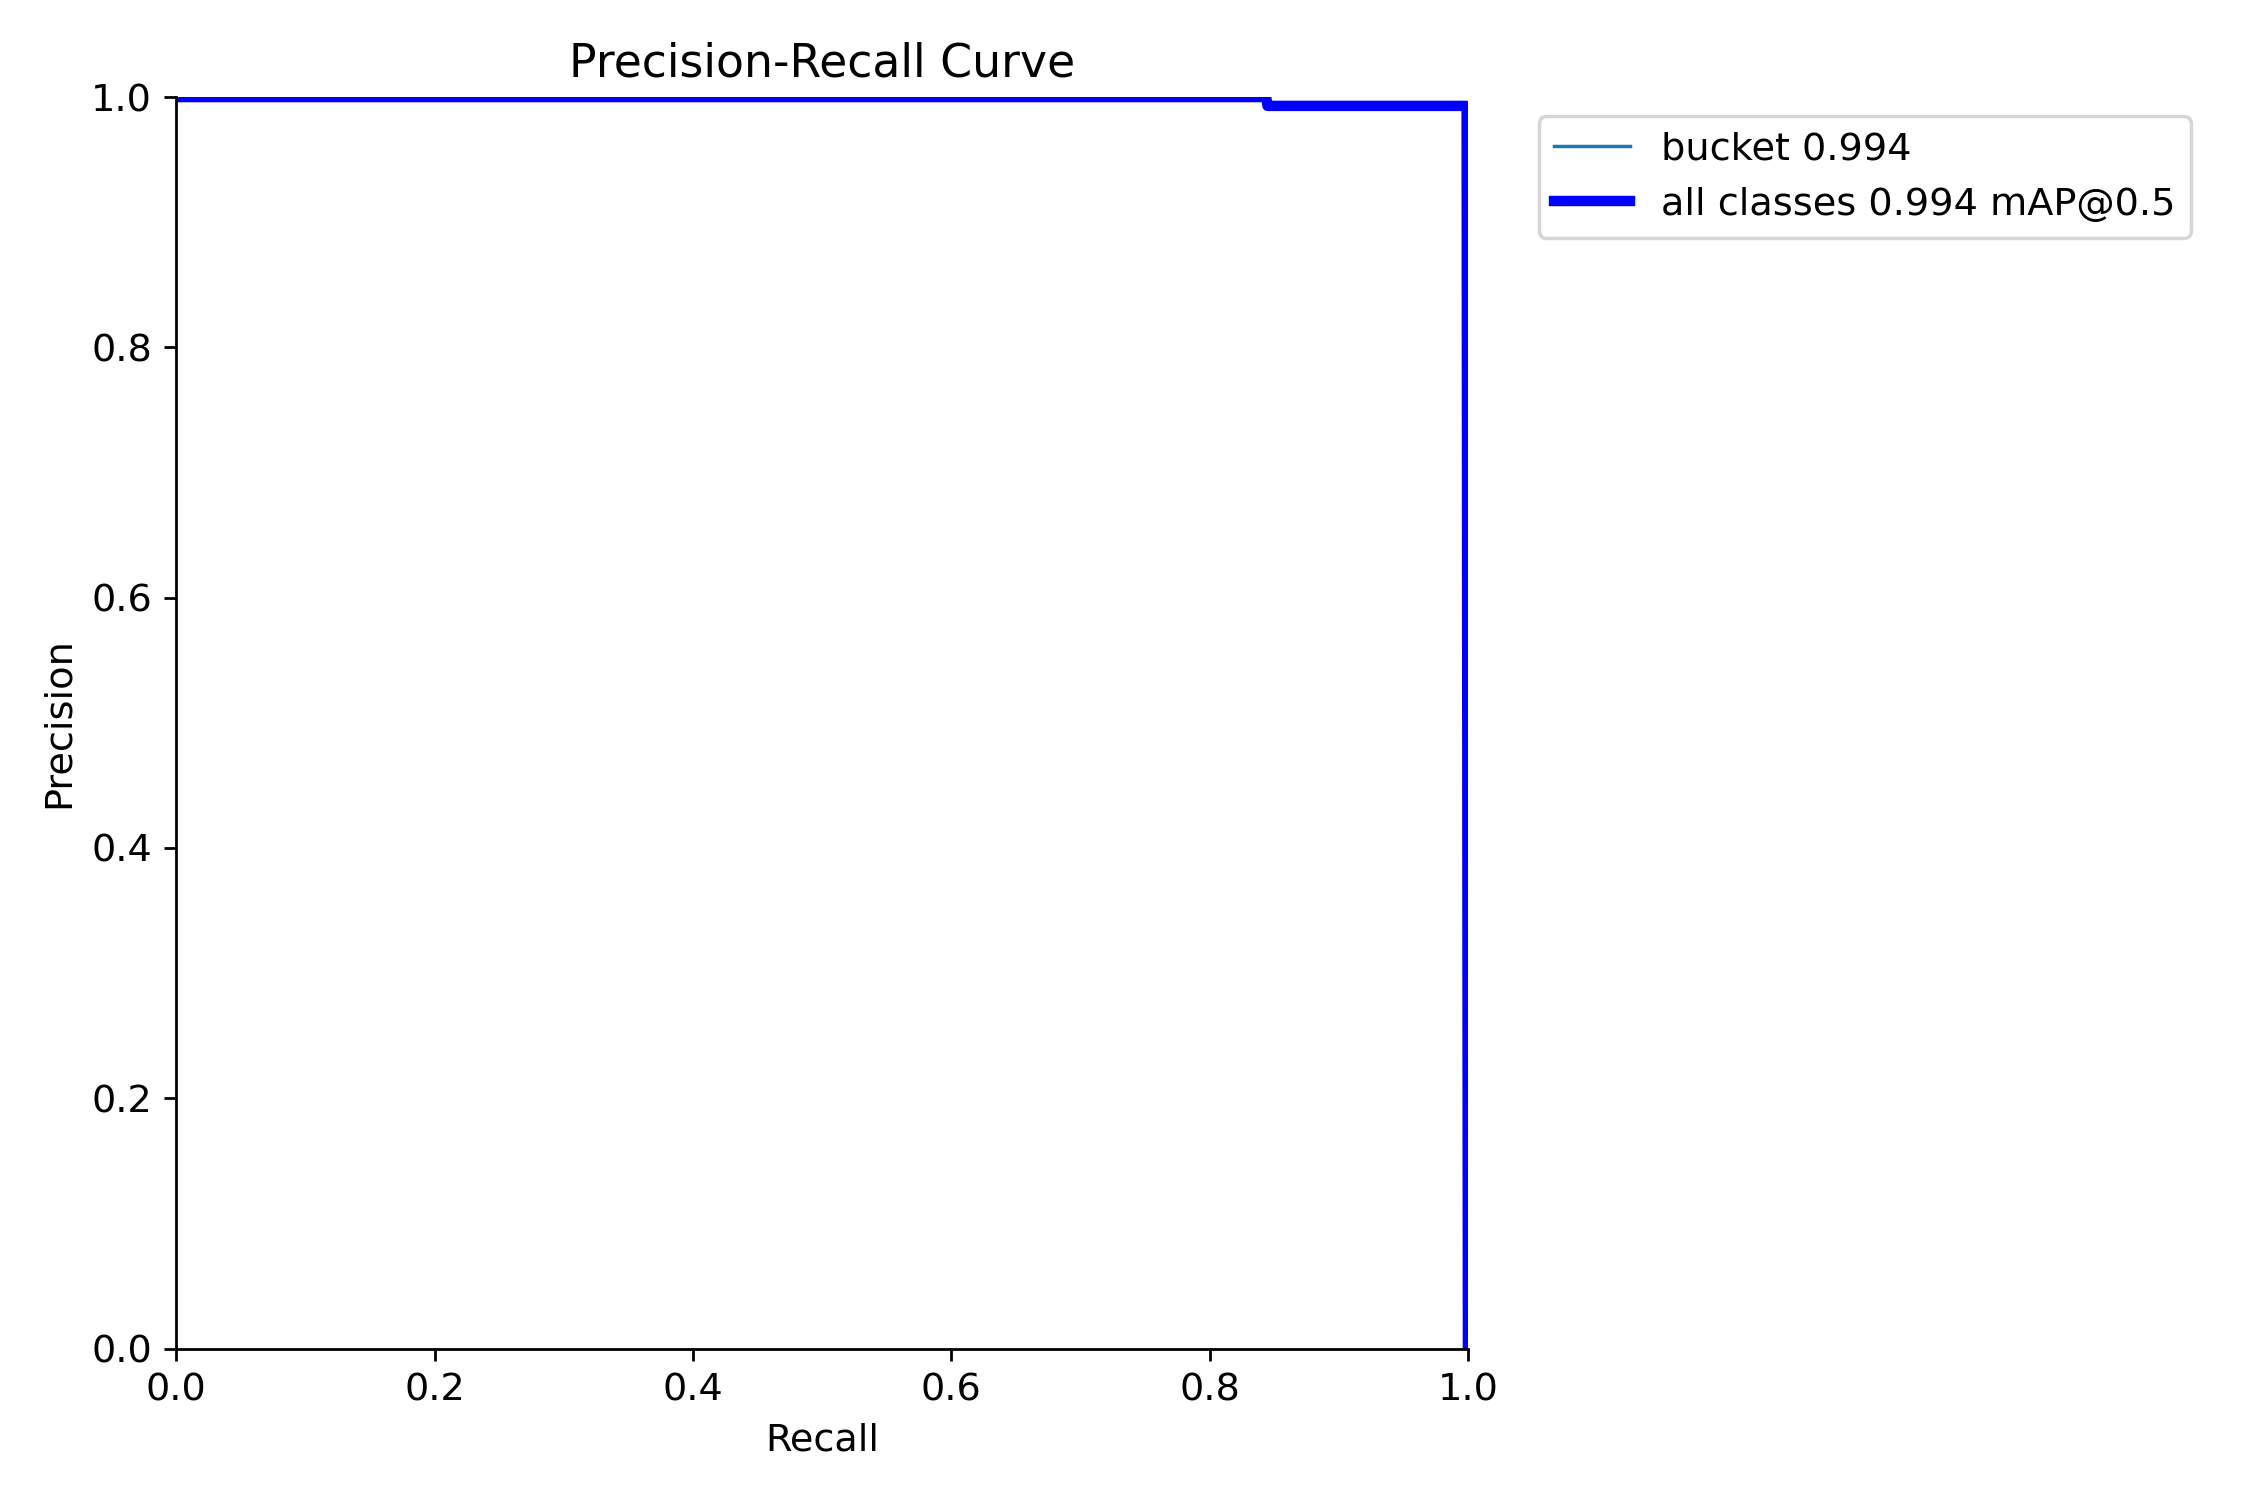

03_test_F1_confidence.png


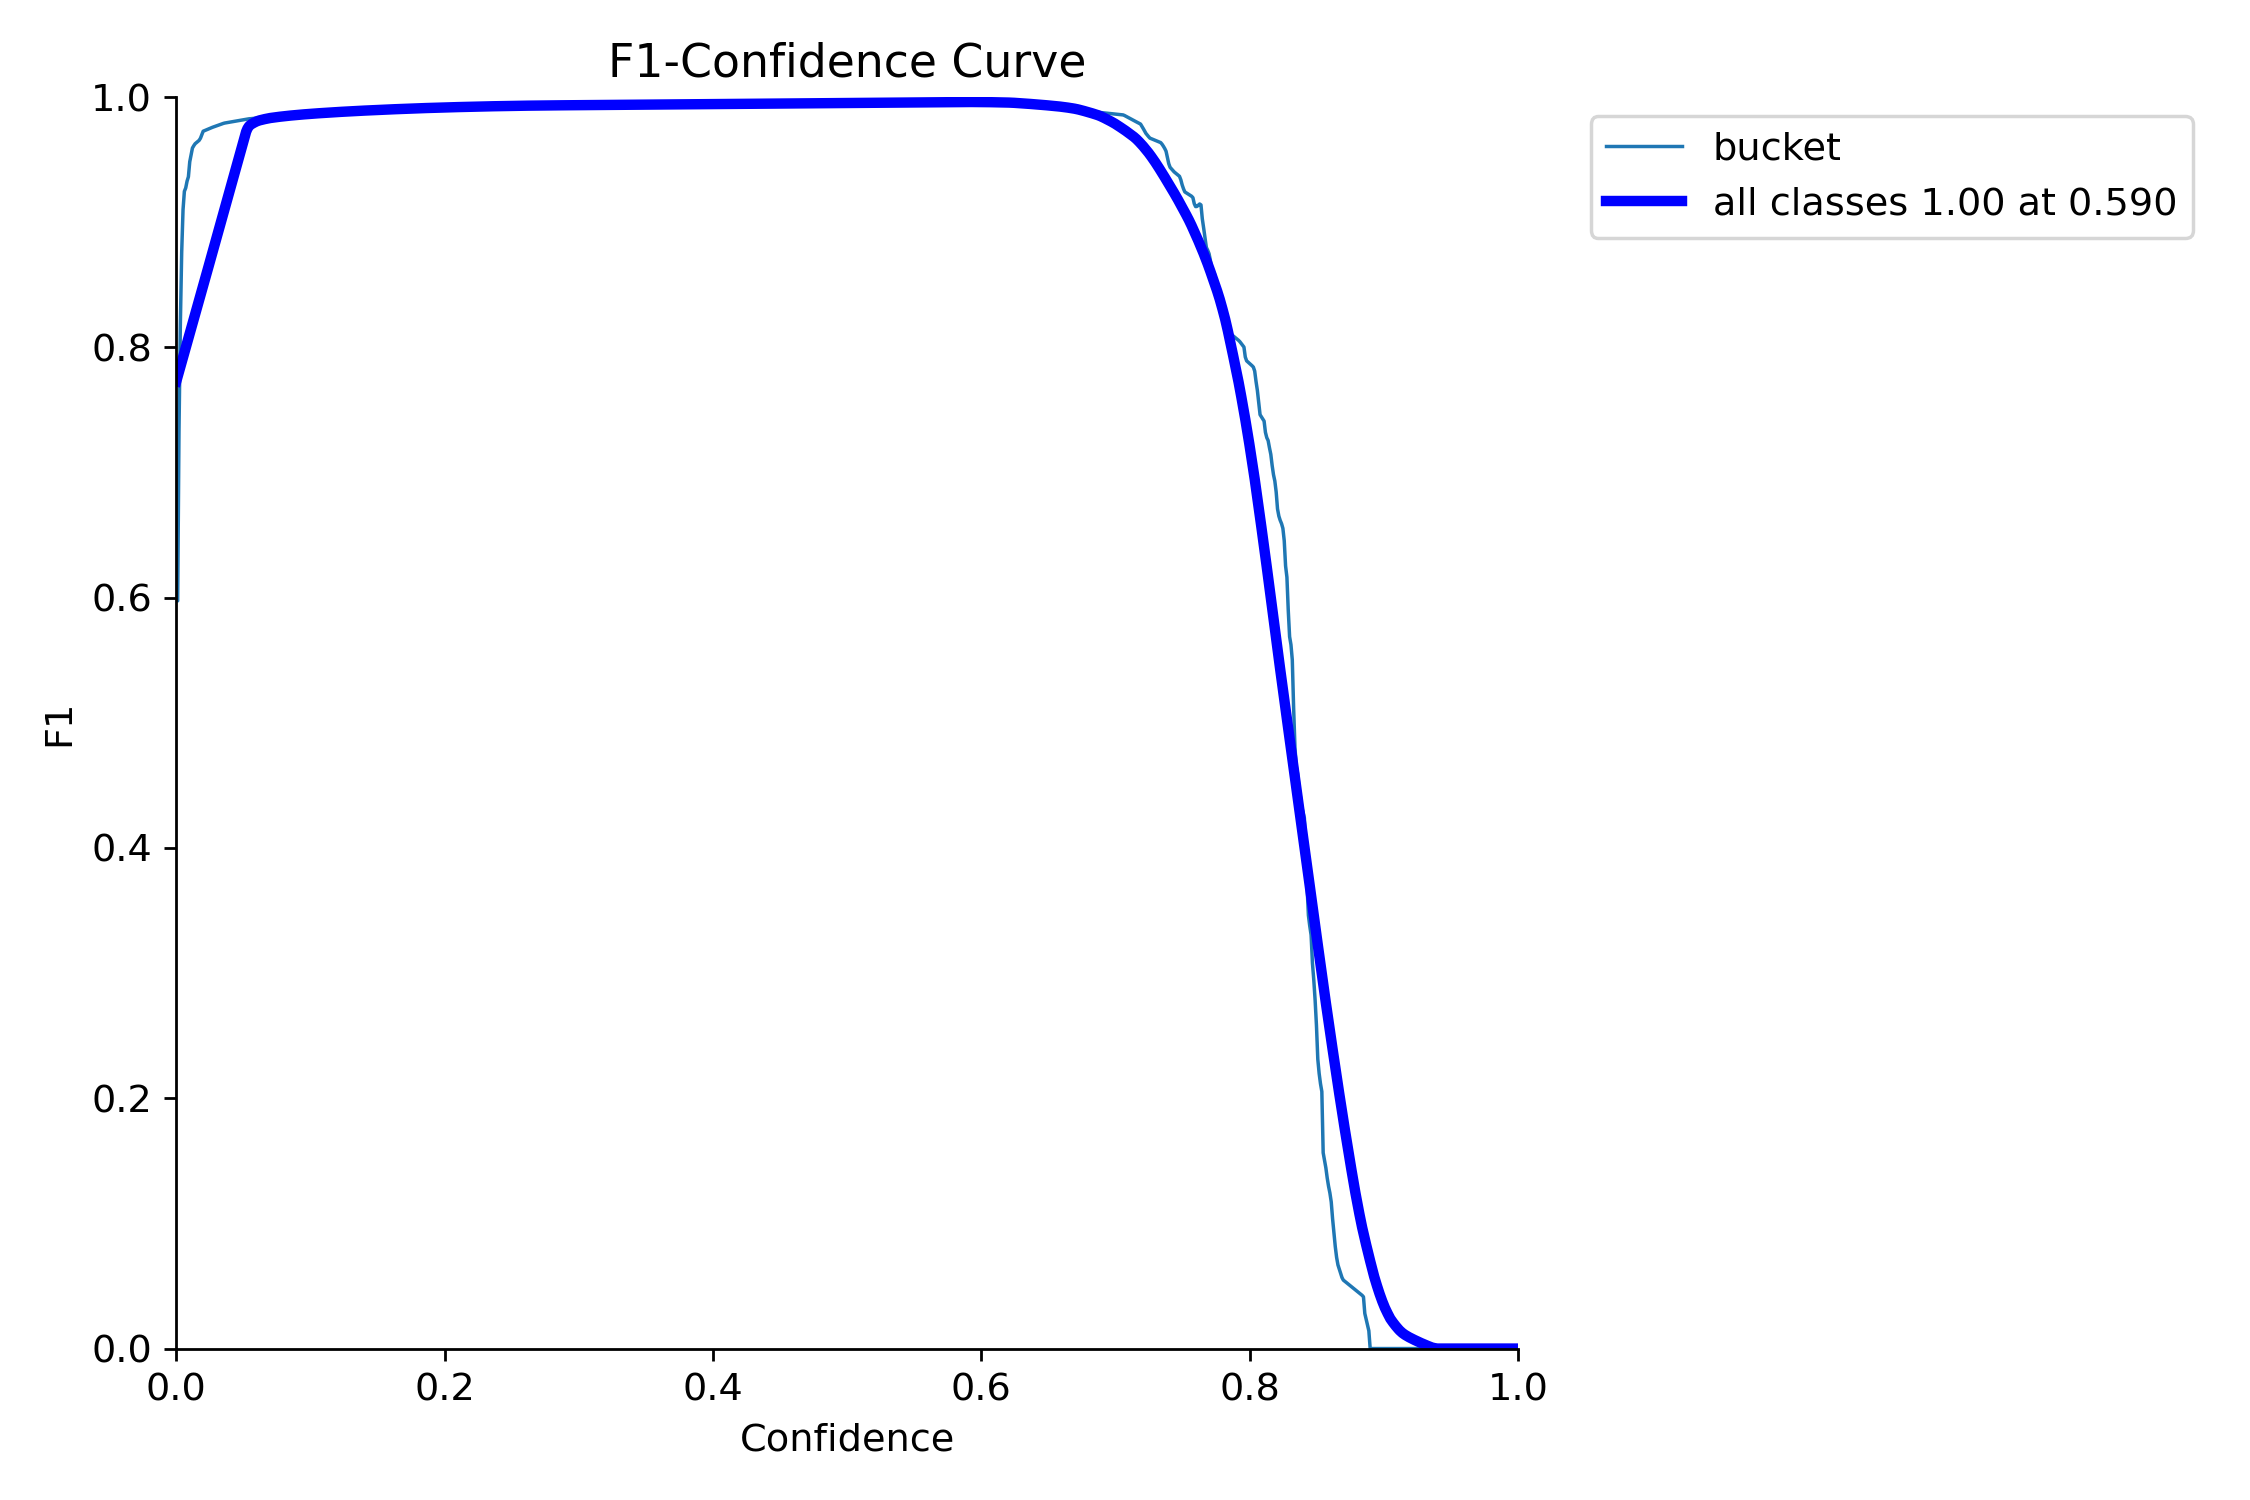

04_test_P_confidence.png


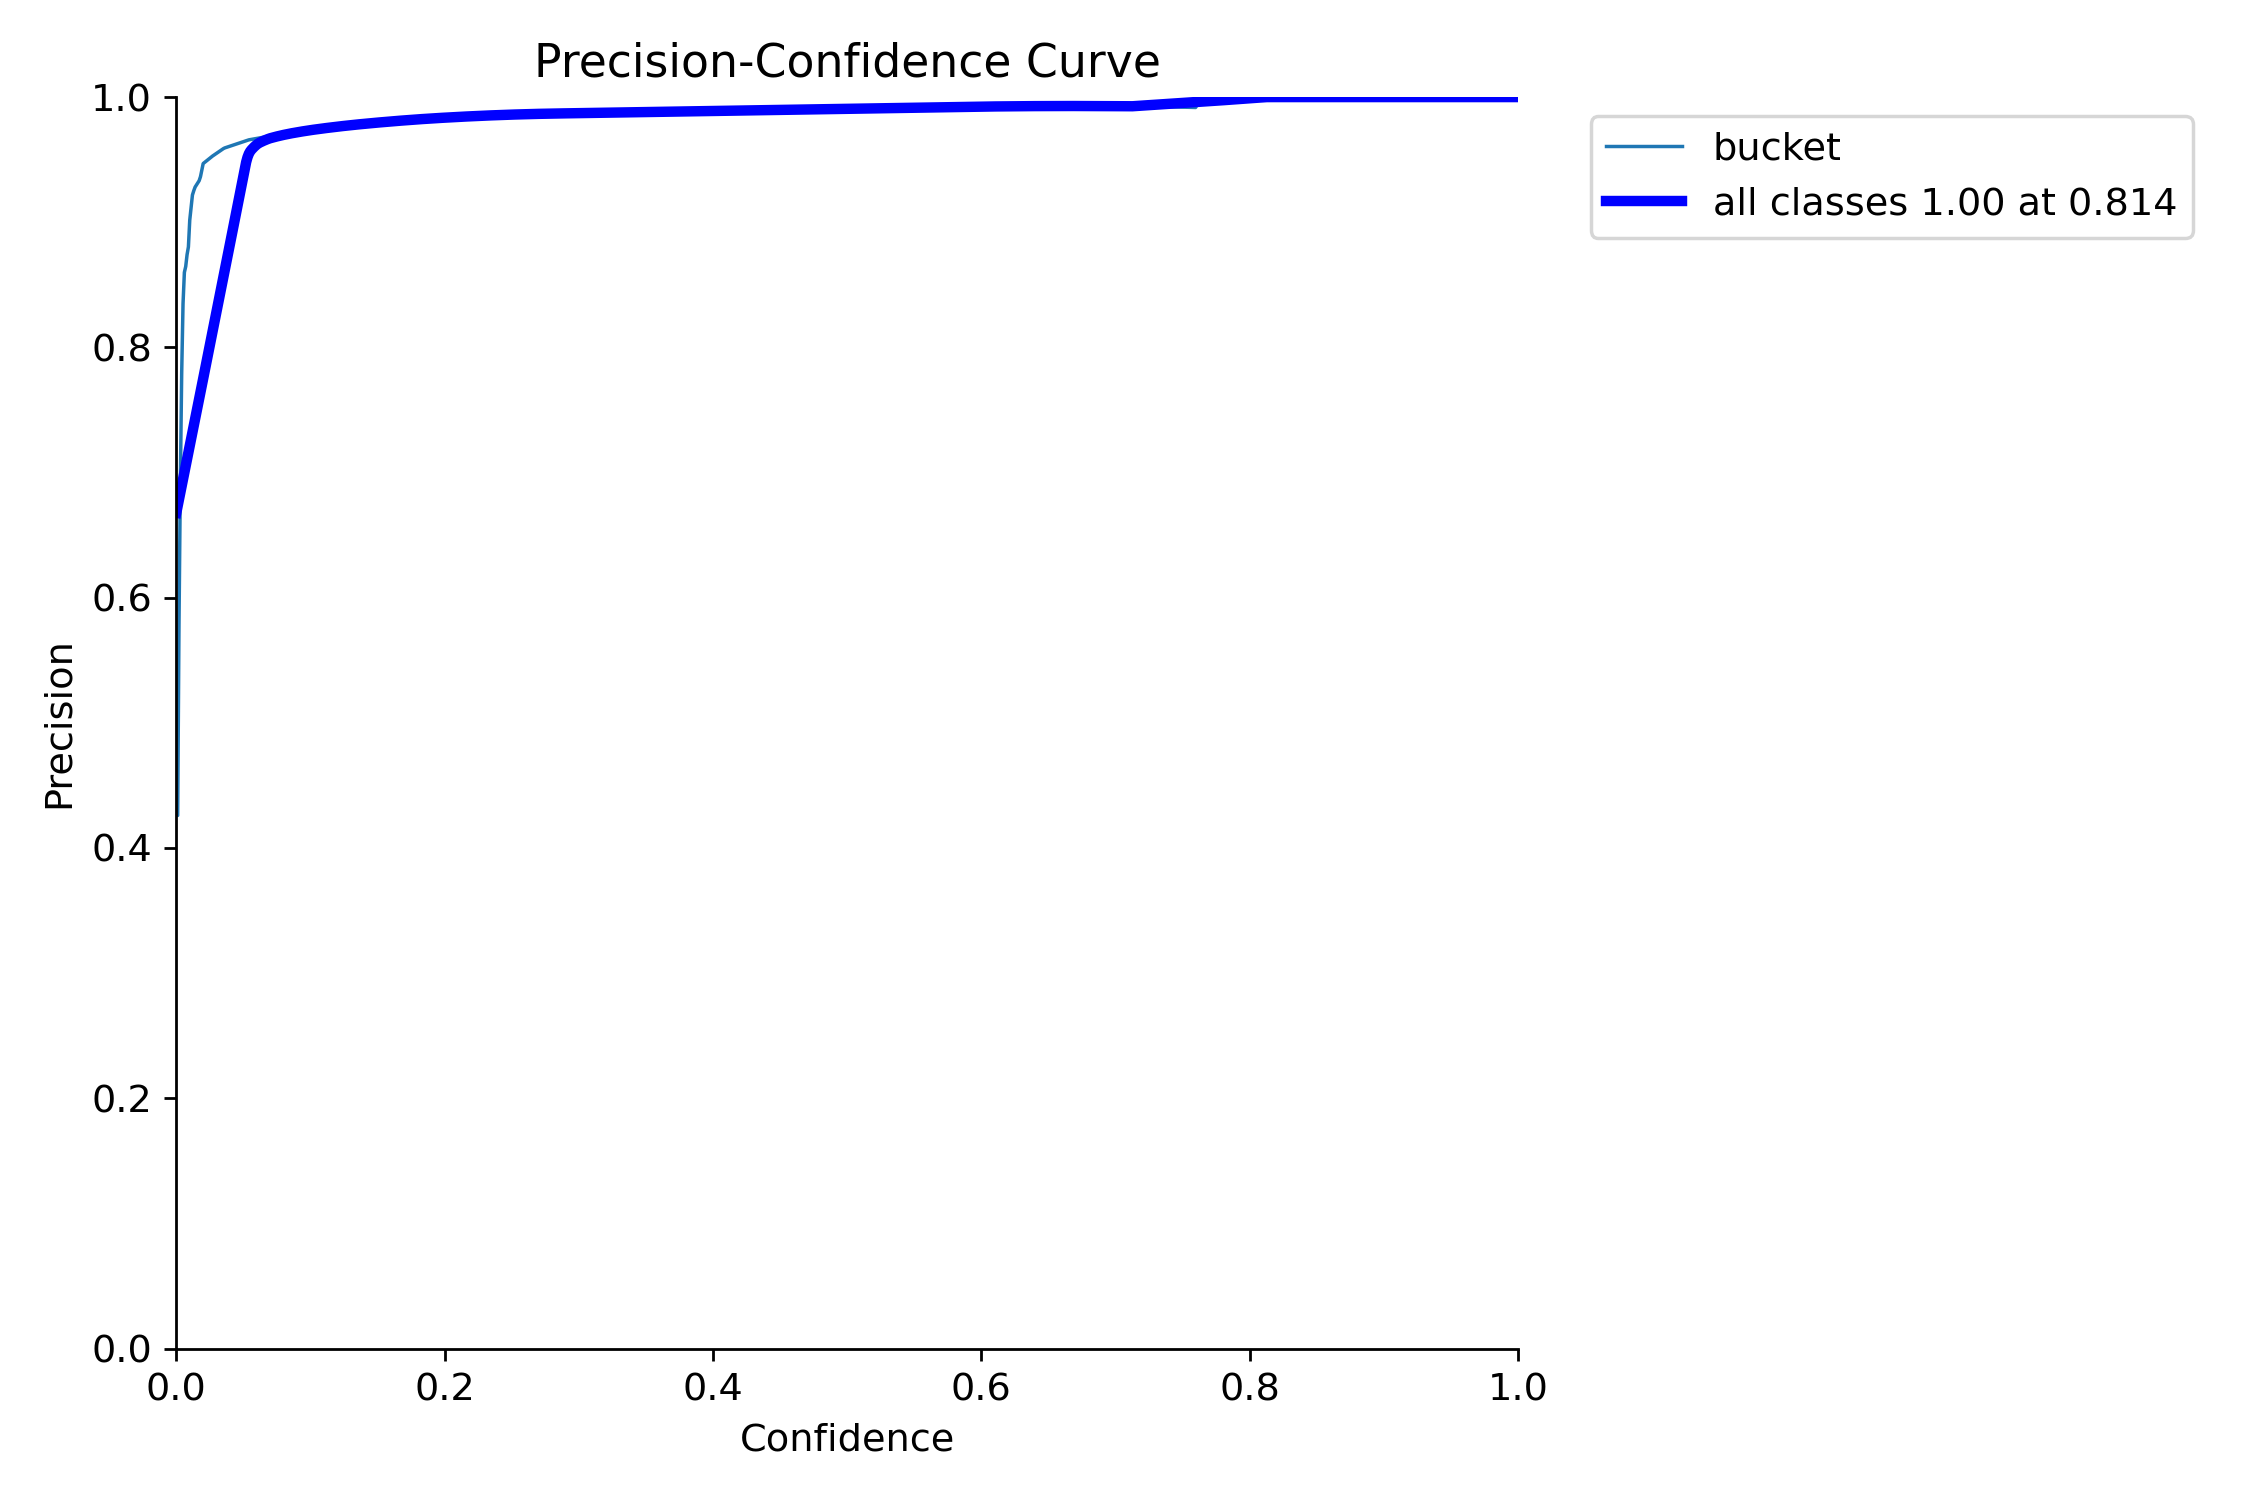

05_test_R_confidence.png


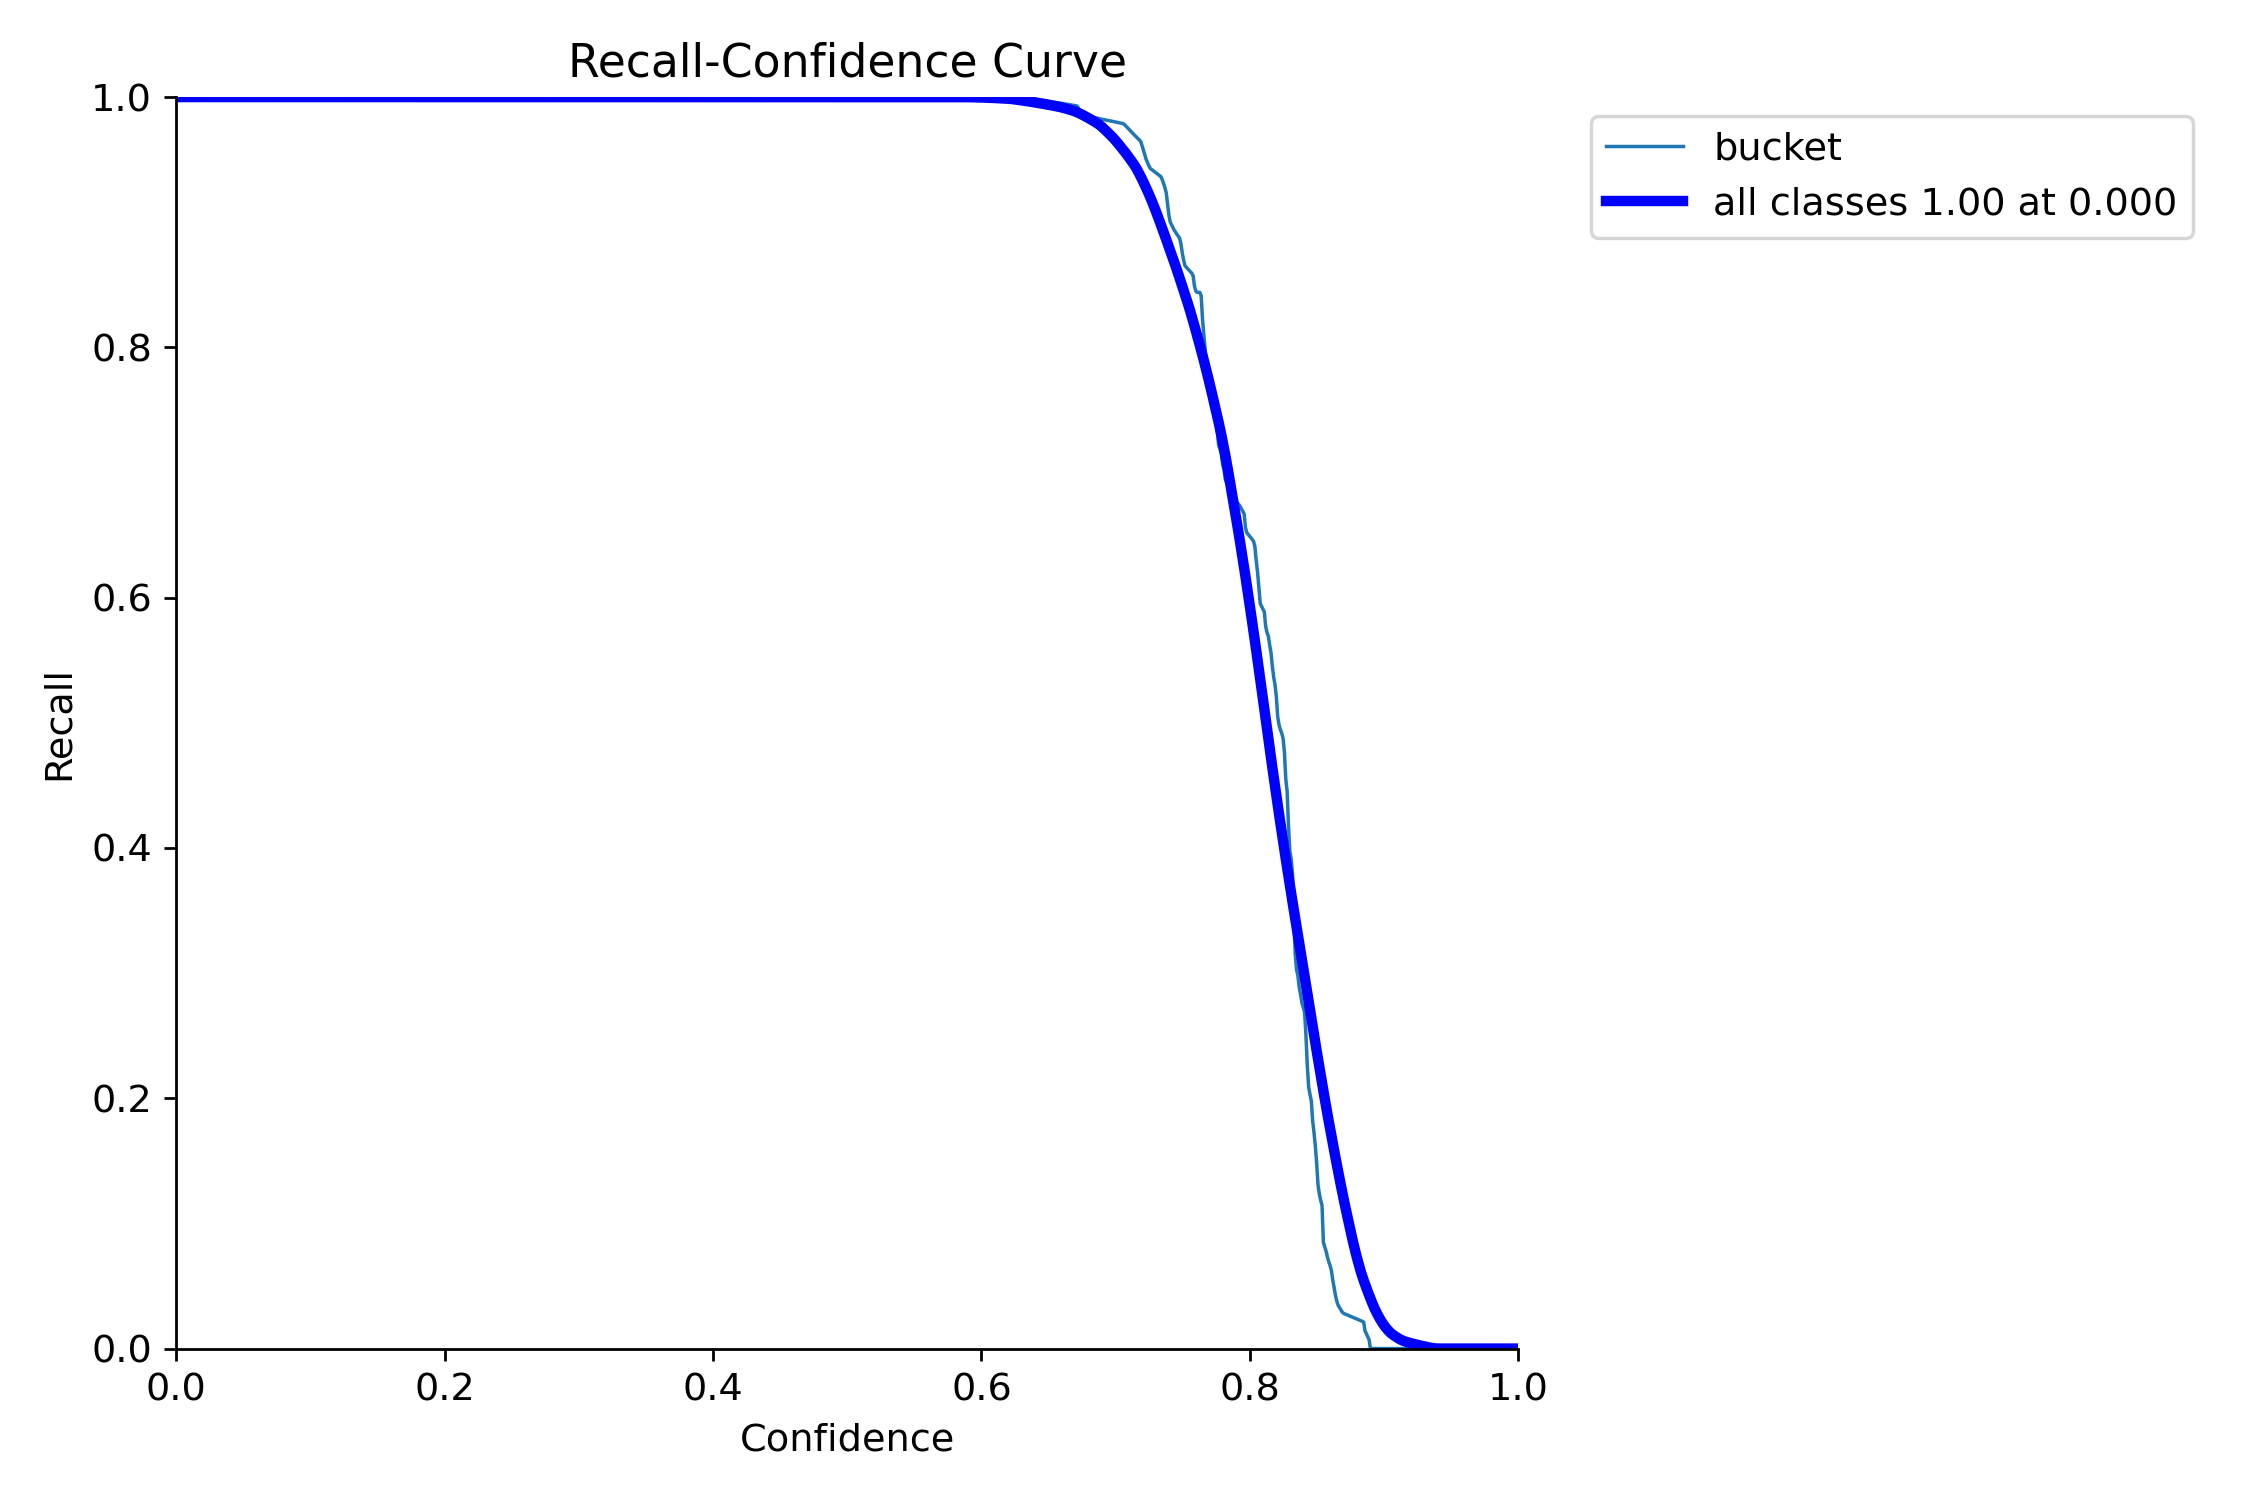

06_test_confusion_matrix.png


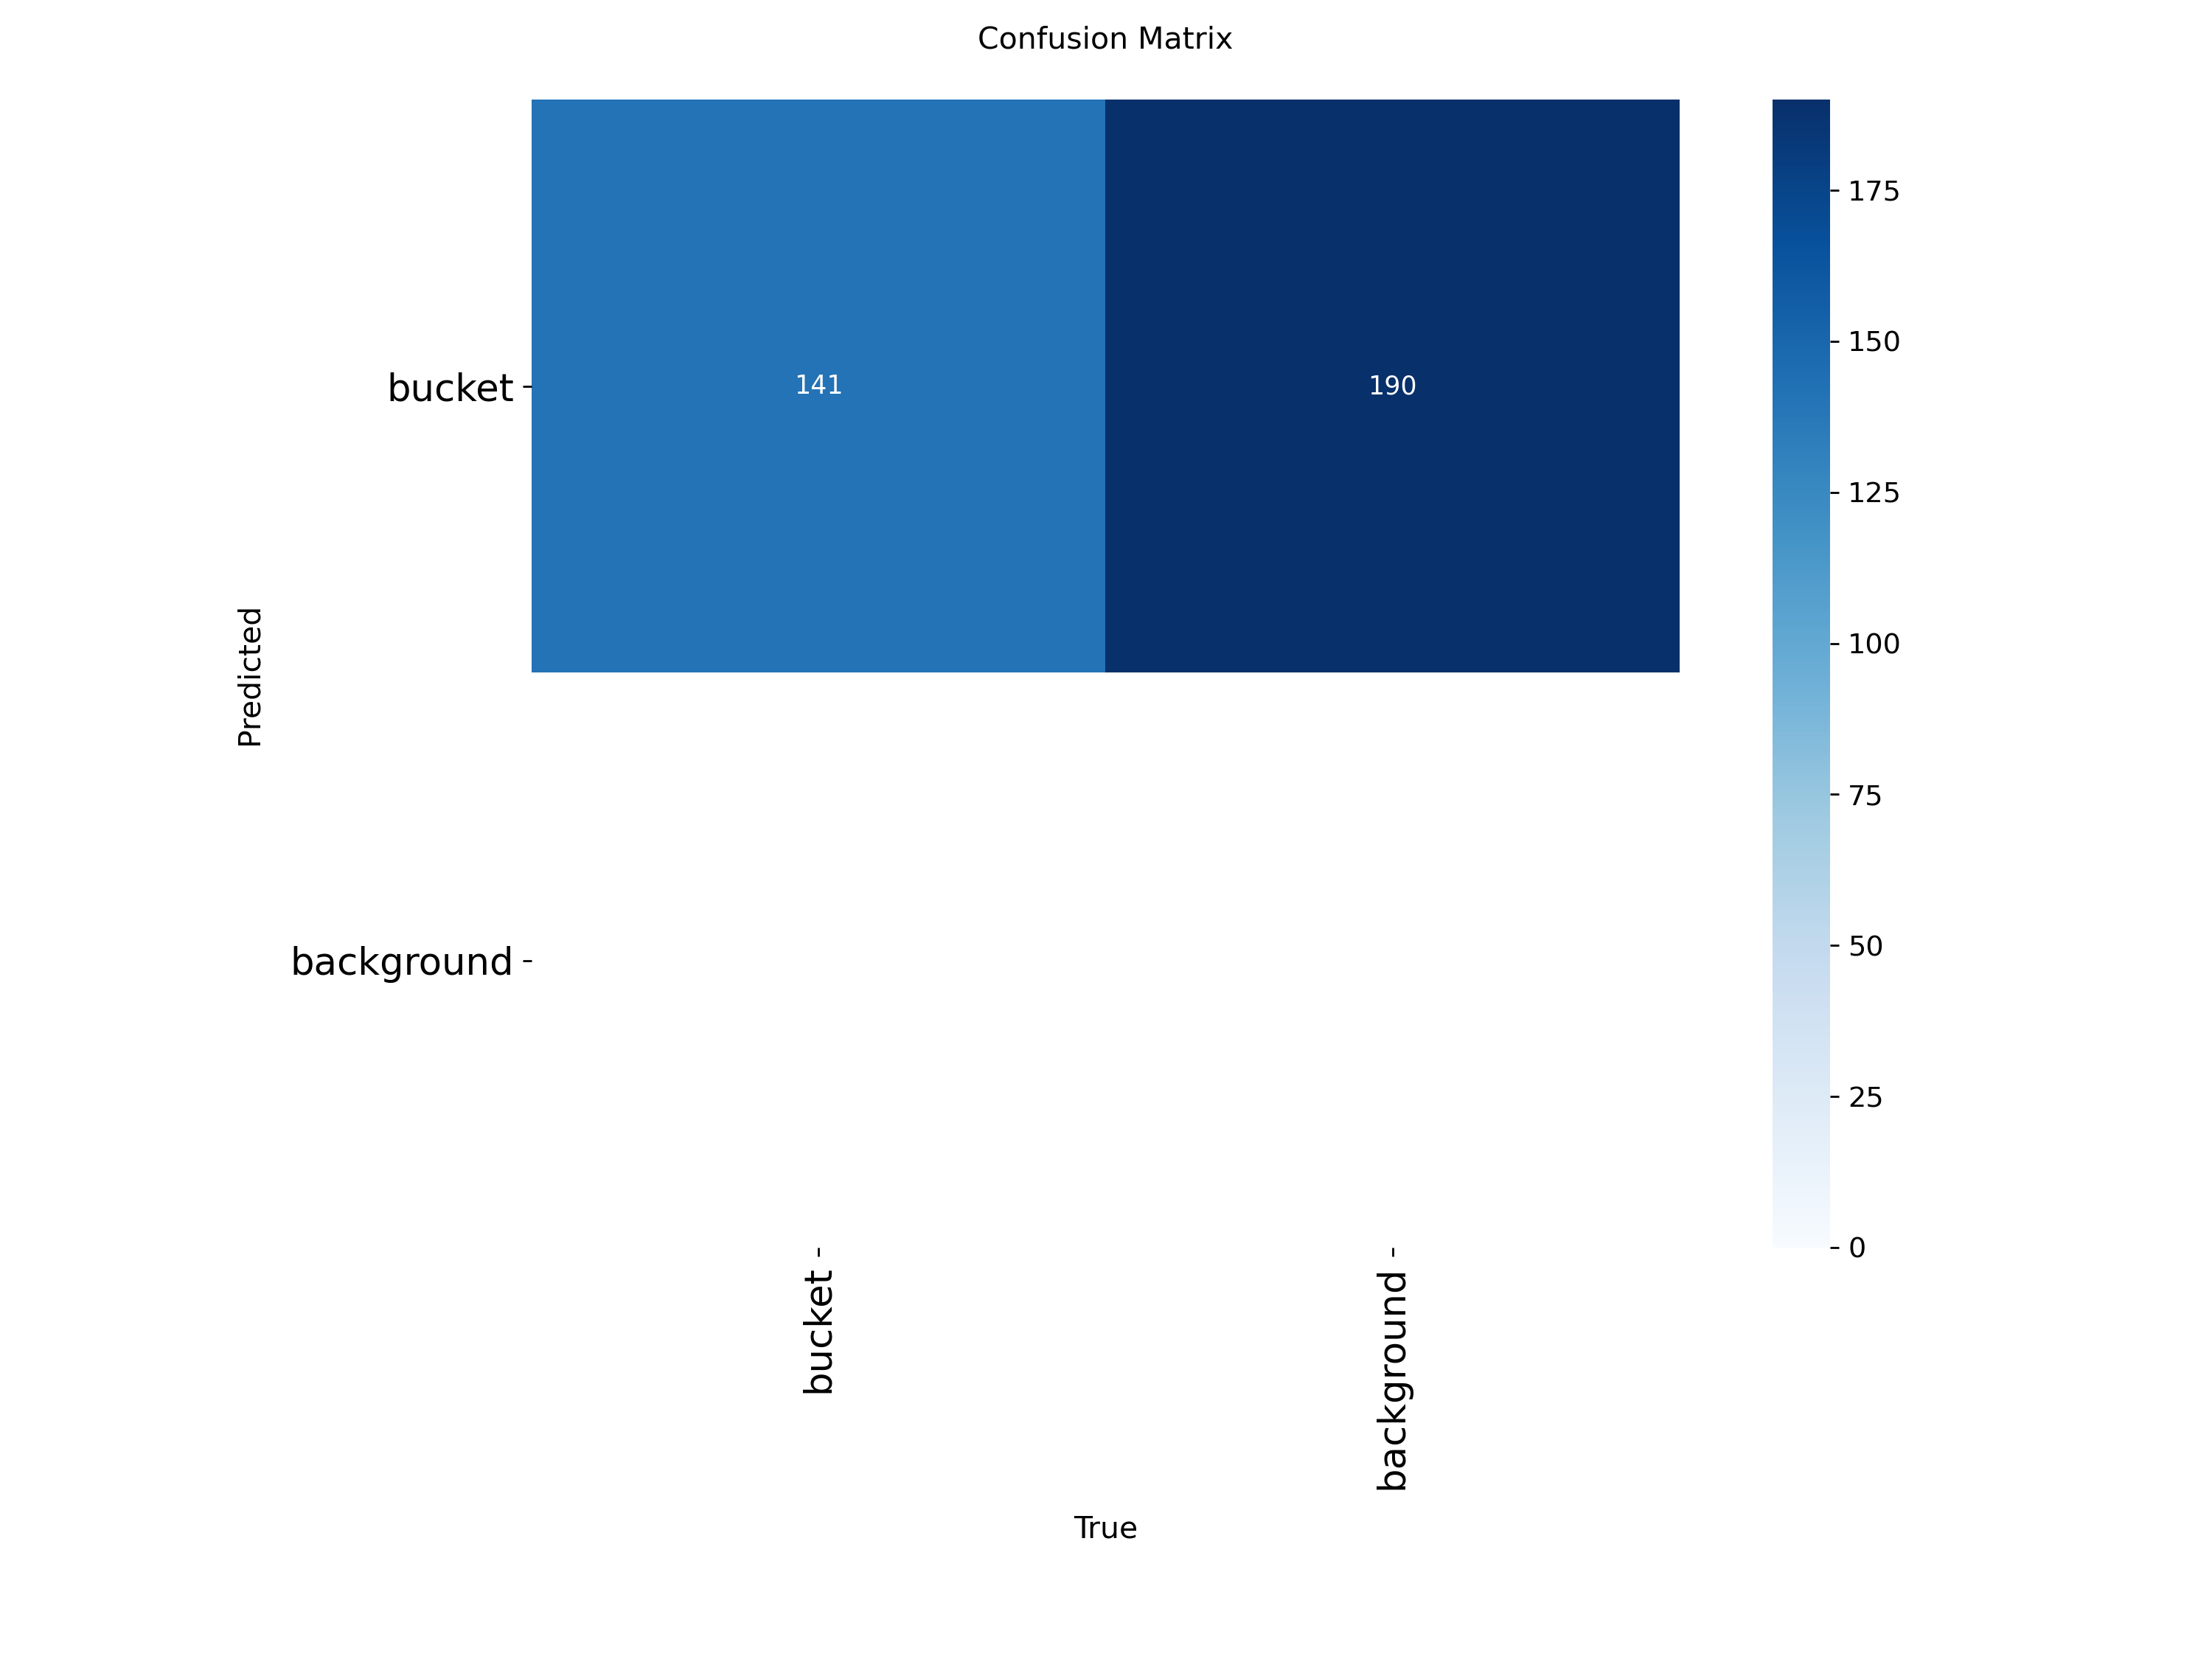

07_test_confusion_matrix_normalized.png


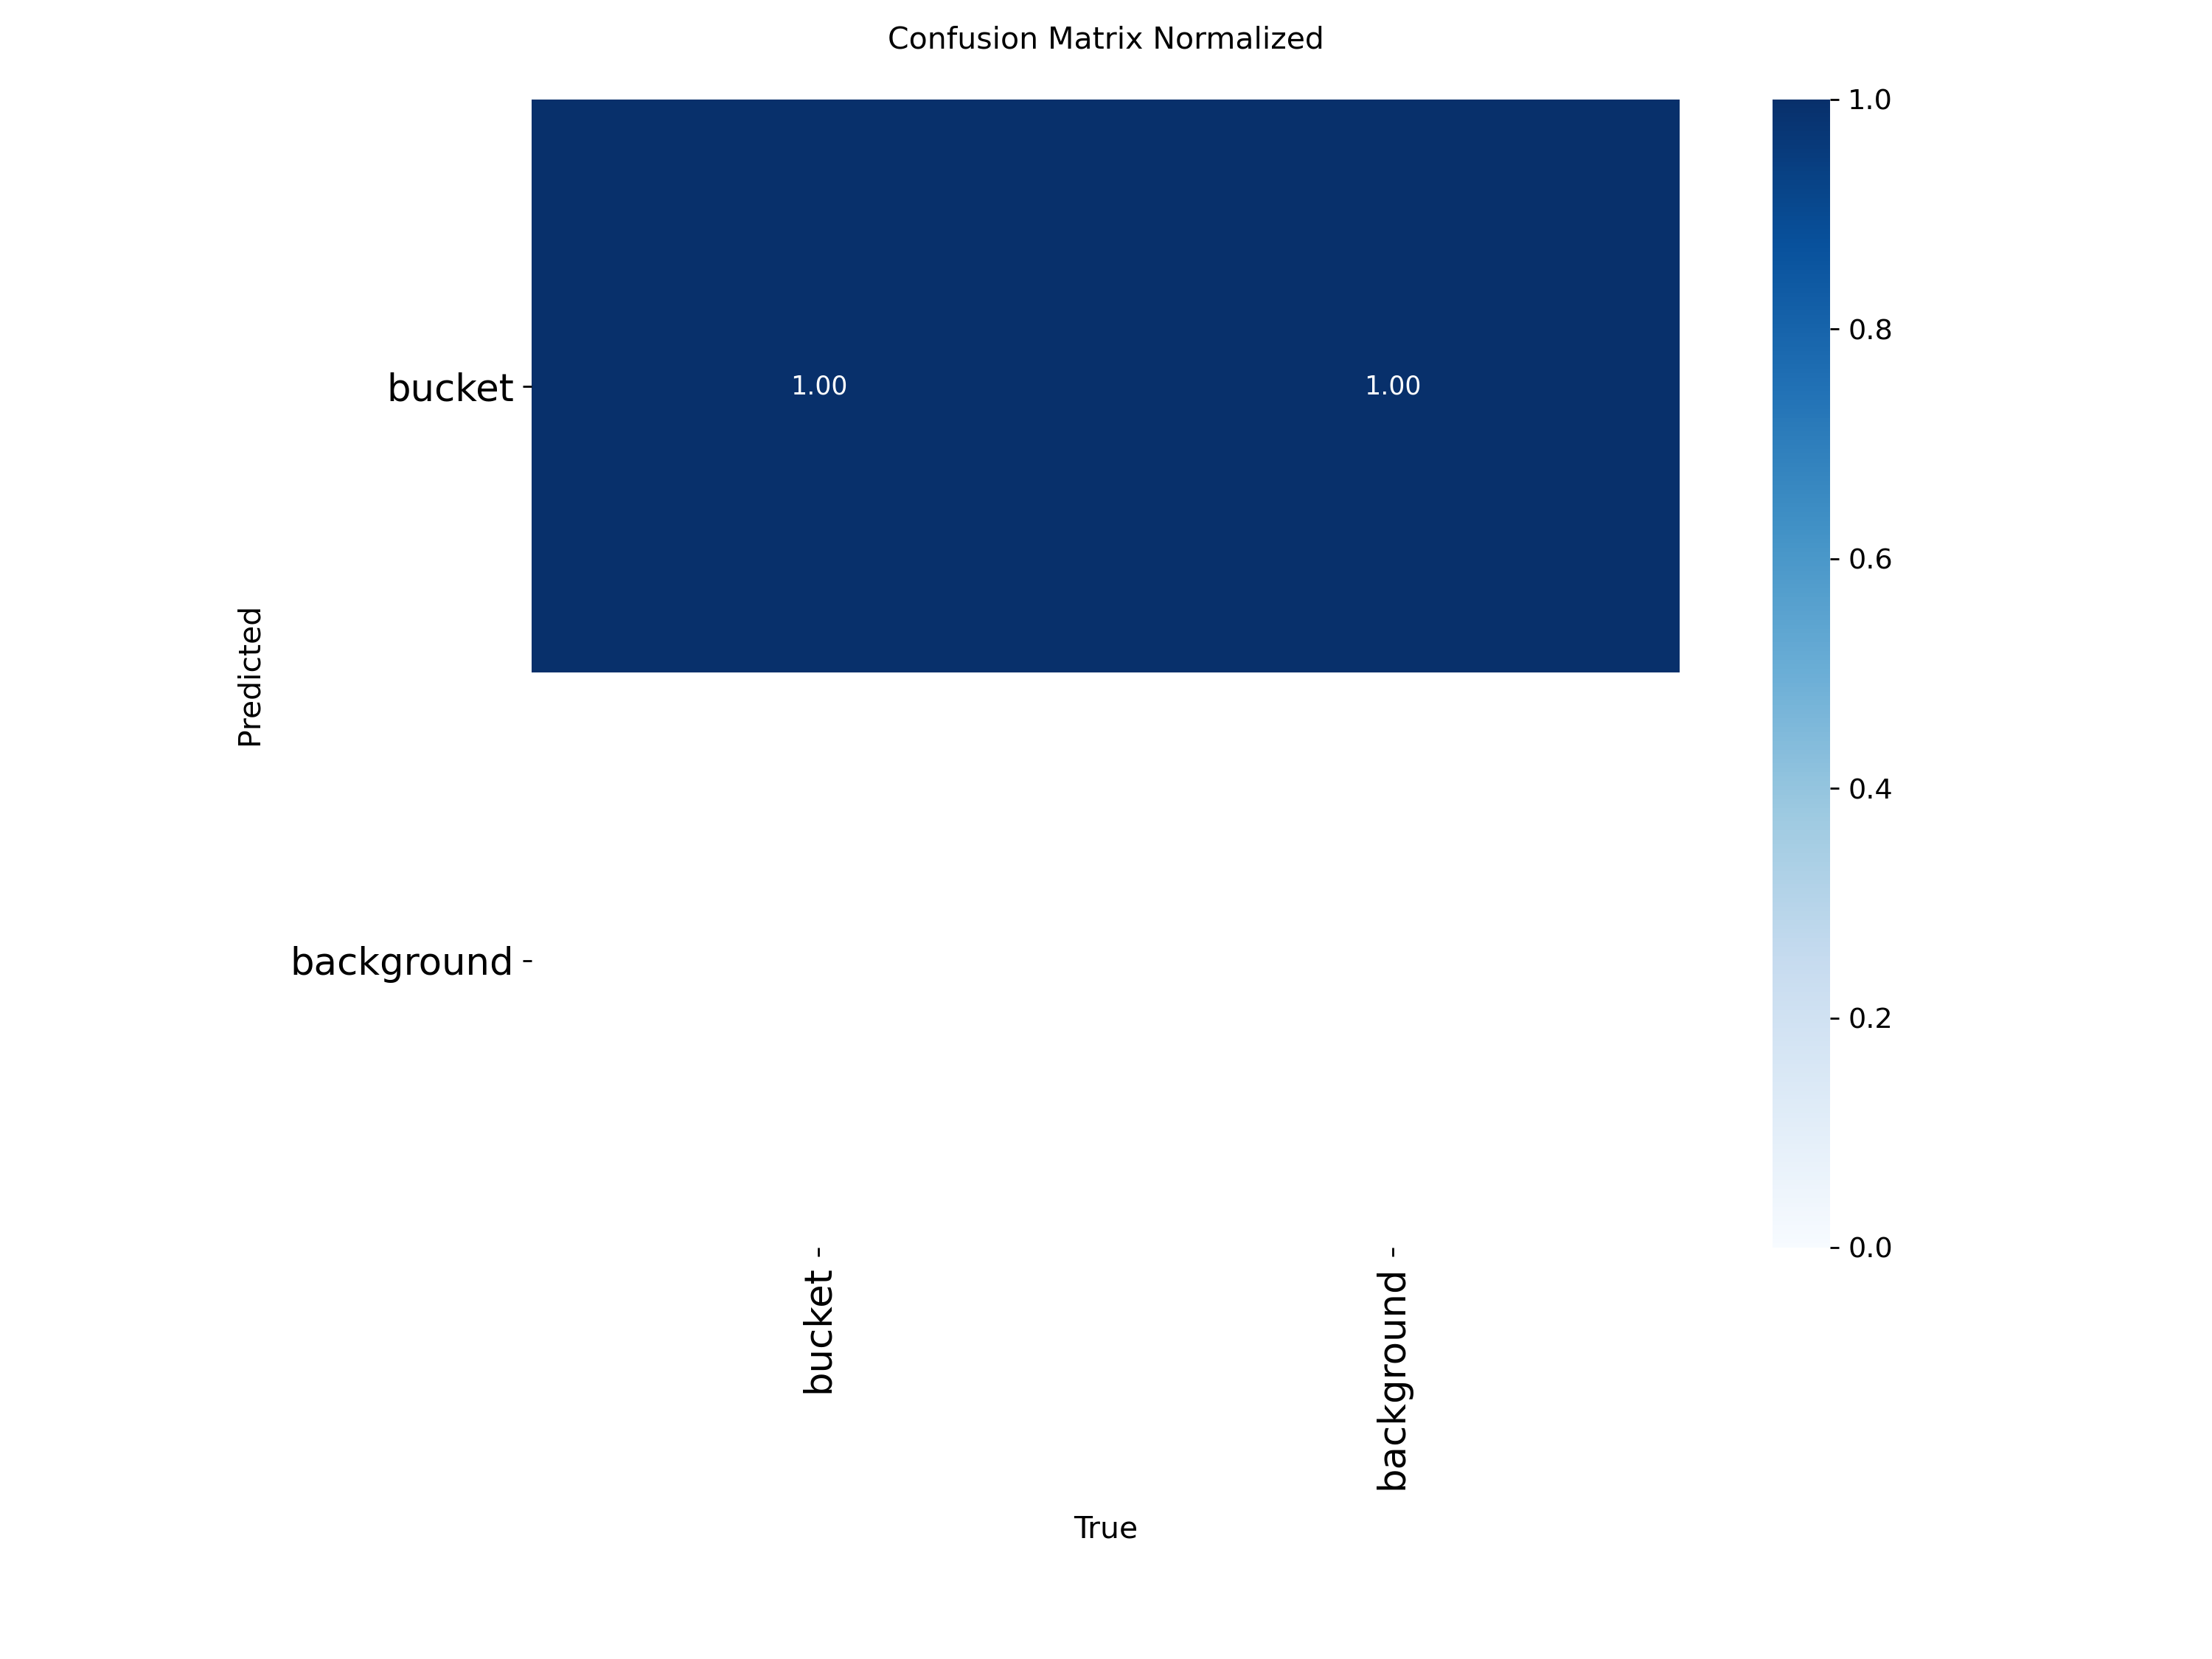

เสร็จแล้ว — ดาวน์โหลดกราฟทั้งหมด: /kaggle/working/thesis_graphs_20261001_180126_586028_graphs.zip


/kaggle/working/thesis_graphs_20261001_180126_586028_graphs.zip

In [31]:
# วางทั้งเซลล์นี้ต่อท้าย notebook ที่เทรนเสร็จ แล้วกด Run
from pathlib import Path
from datetime import datetime
import shutil
import yaml
import torch
from ultralytics import YOLO
from ultralytics.utils.plotting import plot_results
from IPython.display import display, Image, FileLink

RUN_DIR = Path("/kaggle/working/worker_detection/v1_960_s")
DATA_YAML = None  # None = อ่านที่อยู่ dataset จาก args.yaml

args = yaml.safe_load((RUN_DIR / "args.yaml").read_text())
data_yaml = Path(DATA_YAML or args["data"])
best_pt = RUN_DIR / "weights" / "best.pt"
if not best_pt.is_file():
    raise FileNotFoundError(f"ไม่พบโมเดล: {best_pt}")
if not data_yaml.is_file():
    raise FileNotFoundError(f"ไม่พบ dataset: {data_yaml} ให้แก้ DATA_YAML เป็นที่อยู่จริง")

detector = YOLO(str(best_pt))
print("คลาสในโมเดล:", detector.names)
print("กำลังสร้างกราฟจาก best.pt บนชุด Test — ไม่ได้เทรนใหม่")

output = Path("/kaggle/working") / ("thesis_graphs_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"))
graphs = output / "graphs"
graphs.mkdir(parents=True)

# กราฟ Loss, Precision, Recall และ mAP ตาม Epoch จากผลเทรนเดิม
training_plot = RUN_DIR / "results.png"
if not training_plot.is_file():
    history = RUN_DIR / "results.csv"
    if not history.is_file():
        raise FileNotFoundError(f"ไม่พบ results.png หรือ results.csv ใน {RUN_DIR}")
    temp_train = output / "training_plot_source"
    temp_train.mkdir()
    shutil.copy2(history, temp_train / "results.csv")
    plot_results(file=str(temp_train / "results.csv"))
    training_plot = temp_train / "results.png"
shutil.copy2(training_plot, graphs / "01_training_results.png")

# กราฟผล Test ใช้ conf floor ต่ำสำหรับเส้น Precision–Recall
detector.val(
    data=str(data_yaml), split="test", imgsz=int(args.get("imgsz", 960)),
    batch=16, device=0 if torch.cuda.is_available() else "cpu",
    conf=0.001, iou=float(args.get("iou", 0.7)),
    max_det=int(args.get("max_det", 300)), plots=True,
    project=str(output), name="test_evaluation", exist_ok=False,
)
evaluation = output / "test_evaluation"
plots = [
    ("02_test_PR_curve.png", ["BoxPR_curve.png", "PR_curve.png"]),
    ("03_test_F1_confidence.png", ["BoxF1_curve.png", "F1_curve.png"]),
    ("04_test_P_confidence.png", ["BoxP_curve.png", "P_curve.png"]),
    ("05_test_R_confidence.png", ["BoxR_curve.png", "R_curve.png"]),
    ("06_test_confusion_matrix.png", ["confusion_matrix.png"]),
    ("07_test_confusion_matrix_normalized.png", ["confusion_matrix_normalized.png"]),
]
for destination, candidates in plots:
    source = next((evaluation / n for n in candidates if (evaluation / n).is_file()), None)
    if source:
        shutil.copy2(source, graphs / destination)
    else:
        print("ไลบรารีไม่ได้สร้างภาพนี้:", destination)

# แสดงกราฟทันที และ ZIP เฉพาะภาพกราฟ
for image_path in sorted(graphs.glob("*.png")):
    print(image_path.name)
    display(Image(filename=str(image_path), width=950))
zip_path = shutil.make_archive(str(output) + "_graphs", "zip", graphs)
print("เสร็จแล้ว — ดาวน์โหลดกราฟทั้งหมด:", zip_path)
display(FileLink(zip_path))
